# CXR-LT 2024

This notebook mirrors the CXR-LT 2023 examination pass for the 2024 release. It uses `labels.csv` for the combined labeled view and keeps task-specific files available for schema and task checks.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from utils import *

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)

root_dir, data_dir = get_notebook_paths()
cxr_lt_2024_dir = data_dir / "CXR-LT" / "cxr-lt-multi-label-long-tailed-classification-on-chest-x-rays-2.0.0" / "cxr-lt-2024"
mimic_cxr_dir = data_dir / "MIMIC-CXR"
mimic_cxr_jpg_dir = data_dir / "MIMIC-CXR-JPG"

print(f"root_dir: {root_dir}")
print(f"cxr_lt_2024_dir: {cxr_lt_2024_dir}")
print(f"mimic_cxr_dir exists: {mimic_cxr_dir.exists()}")
print(f"mimic_cxr_jpg_dir exists: {mimic_cxr_jpg_dir.exists()}")


root_dir: /home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis
cxr_lt_2024_dir: /home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/CXR-LT/cxr-lt-multi-label-long-tailed-classification-on-chest-x-rays-2.0.0/cxr-lt-2024
mimic_cxr_dir exists: True
mimic_cxr_jpg_dir exists: True


In [2]:
CSV_FILES = {
    "labels": "labels.csv",
    "train": "train_labeled.csv",
    "development_task1": "development_labeled_task1.csv",
    "development_task2": "development_labeled_task2.csv",
    "development_task3": "development_labeled_task3.csv",
    "test_task1": "test_labeled_task1.csv",
    "test_task2": "test_labeled_task2.csv",
    "test_task3": "test_labeled_task3.csv",
}

datasets = load_csv_map(cxr_lt_2024_dir, CSV_FILES)
global_df = datasets["labels"].copy()
label_cols = label_columns(global_df)
analysis_splits = {split_name: df.copy() for split_name, df in global_df.groupby("split", sort=False)}
global_frames = {"global": global_df}
task_splits = {name: df for name, df in datasets.items() if name != "labels"}

print(f"Loaded {len(datasets)} files")
print(f"Detected {len(label_cols)} labels")
print(f"Global analysis rows: {len(global_df):,}")
print(f"Path column: {detect_path_column(global_df)}")
label_cols


Loaded 8 files
Detected 45 labels
Global analysis rows: 377,110
Path column: fpath


['Adenopathy',
 'Atelectasis',
 'Azygos Lobe',
 'Bulla',
 'Calcification of the Aorta',
 'Cardiomegaly',
 'Cardiomyopathy',
 'Clavicle Fracture',
 'Consolidation',
 'Edema',
 'Emphysema',
 'Enlarged Cardiomediastinum',
 'Fibrosis',
 'Fissure',
 'Fracture',
 'Granuloma',
 'Hernia',
 'Hilum',
 'Hydropneumothorax',
 'Infarction',
 'Infiltration',
 'Kyphosis',
 'Lobar Atelectasis',
 'Lung Lesion',
 'Lung Opacity',
 'Mass',
 'Nodule',
 'Normal',
 'Osteopenia',
 'Pleural Effusion',
 'Pleural Other',
 'Pleural Thickening',
 'Pneumomediastinum',
 'Pneumonia',
 'Pneumoperitoneum',
 'Pneumothorax',
 'Pulmonary Embolism',
 'Pulmonary Hypertension',
 'Rib Fracture',
 'Round(ed) Atelectasis',
 'Scoliosis',
 'Subcutaneous Emphysema',
 'Support Devices',
 'Tortuous Aorta',
 'Tuberculosis']

## 1) Quick File And Split Overview


In [3]:
for name, df in datasets.items():
    preview_dataset(name, df)

split_overview_df = build_split_overview(analysis_splits, label_cols)
display(split_overview_df)



labels
shape: (377110, 52)
duplicate dicom_id rows: 0


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,fpath,Adenopathy,Atelectasis,Azygos Lobe,Bulla,Calcification of the Aorta,Cardiomegaly,Cardiomyopathy,Clavicle Fracture,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fissure,Fracture,Granuloma,Hernia,Hilum,Hydropneumothorax,Infarction,Infiltration,Kyphosis,Lobar Atelectasis,Lung Lesion,Lung Opacity,Mass,Nodule,Normal,Osteopenia,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Pulmonary Embolism,Pulmonary Hypertension,Rib Fracture,Round(ed) Atelectasis,Scoliosis,Subcutaneous Emphysema,Support Devices,Tortuous Aorta,Tuberculosis,split
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,s50414267,PA,postero-anterior,files/p10/p10000032/s50414267/02aa804e-bde0afd...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,train
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,s50414267,LATERAL,lateral,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,train
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,s53189527,PA,postero-anterior,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,train


,missing_count,missing_pct
ViewCodeSequence_CodeMeaning,16497,4.374586
ViewPosition,15769,4.181539



train
shape: (258871, 46)
duplicate dicom_id rows: 0


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,fpath,Adenopathy,Atelectasis,Azygos Lobe,Calcification of the Aorta,Cardiomegaly,Clavicle Fracture,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fissure,Fracture,Granuloma,Hernia,Hydropneumothorax,Infarction,Infiltration,Kyphosis,Lobar Atelectasis,Lung Lesion,Lung Opacity,Mass,Nodule,Normal,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Pulmonary Embolism,Pulmonary Hypertension,Rib Fracture,Round(ed) Atelectasis,Subcutaneous Emphysema,Support Devices,Tortuous Aorta,Tuberculosis
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,s50414267,PA,postero-anterior,files/p10/p10000032/s50414267/02aa804e-bde0afd...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,s50414267,LATERAL,lateral,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,s53189527,PA,postero-anterior,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


...

,missing_count,missing_pct
ViewCodeSequence_CodeMeaning,23,5.665025
ViewPosition,22,5.418719



test_task3
shape: (78946, 11)
duplicate dicom_id rows: 0


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,fpath,Bulla,Cardiomyopathy,Hilum,Osteopenia,Scoliosis
0,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738,10000935,s50578979,AP,antero-posterior,files/p10/p10000935/s50578979/d0b71acc-b5a6204...,0,0,1,0,0
1,3be619d1-506a66cf-ff1ab8a1-2efb77bb-fe7d59fc,10000935,s51178377,LATERAL,lateral,files/p10/p10000935/s51178377/3be619d1-506a66c...,0,0,1,0,0
2,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b,10000935,s51178377,AP,antero-posterior,files/p10/p10000935/s51178377/9b314ad7-fbcb042...,0,0,1,0,0


,missing_count,missing_pct
ViewCodeSequence_CodeMeaning,3589,4.546145
ViewPosition,3426,4.339675


,split,rows,unique_subjects,unique_studies,unique_dicoms,missing_ViewPosition,missing_ViewCodeMeaning,avg_labels_per_image,median_labels_per_image,Normal_count,Normal_rate_pct
0,train,258871,45480,155823,258871,10734,11222,2.746318,2.0,34292,13.246752
1,test,78946,13078,48212,78946,3426,3589,2.859638,3.0,9720,12.312213
2,val,39293,6821,23800,39293,1609,1686,2.759448,2.0,5088,12.948871


## 2) Task File Schema Checks


In [4]:
task_schema_df = pd.DataFrame(
    [
        {
            "file": name,
            "rows": len(df),
            "columns": len(df.columns),
            "labels": len(label_columns(df)),
            "path_column": detect_path_column(df),
            "subjects": df["subject_id"].nunique(),
            "studies": df["study_id"].nunique(),
            "dicoms": df["dicom_id"].nunique(),
        }
        for name, df in task_splits.items()
    ]
)
display(task_schema_df)

task_label_sets = {name: set(label_columns(df)) for name, df in task_splits.items()}
label_membership_df = pd.DataFrame(
    [
        {"label": label, **{name: label in labels for name, labels in task_label_sets.items()}}
        for label in sorted(set().union(*task_label_sets.values()))
    ]
)
display(label_membership_df)


,file,rows,columns,labels,path_column,subjects,studies,dicoms
0,train,258871,46,40,fpath,45480,155823,258871
1,development_task1,39293,46,40,fpath,6821,23800,39293
2,development_task2,39293,32,26,fpath,6821,23800,39293
3,development_task3,39293,11,5,fpath,6821,23800,39293
4,test_task1,78946,46,40,fpath,13078,48212,78946
5,test_task2,406,32,26,fpath,330,406,406
6,test_task3,78946,11,5,fpath,13078,48212,78946


,label,train,development_task1,development_task2,development_task3,test_task1,test_task2,test_task3
0,Adenopathy,True,True,False,False,True,False,False
1,Atelectasis,True,True,True,False,True,True,False
2,Azygos Lobe,True,True,False,False,True,False,False
3,Bulla,False,False,False,True,False,False,True
4,Calcification of the Aorta,True,True,True,False,True,True,False
5,Cardiomegaly,True,True,True,False,True,True,False
6,Cardiomyopathy,False,False,False,True,False,False,True
7,Clavicle Fracture,True,True,False,False,True,False,False
8,Consolidation,True,True,True,False,True,True,False
9,Edema,True,True,True,False,True,True,False


## 3) Global Dataset Statistics


,scope,rows,unique_subjects,unique_studies,unique_dicoms,missing_ViewPosition,missing_ViewCodeMeaning,avg_labels_per_image,median_labels_per_image,Normal_count,Normal_rate_pct
0,global,377110,65379,227835,377110,15769,16497,2.771409,2.0,49100,13.020074


,split,label,positive_count,positive_rate_pct
0,global,Support Devices,126776,33.617777
1,global,Lung Opacity,114056,30.244756
2,global,Cardiomegaly,109297,28.982790
3,global,Hilum,99760,26.453820
4,global,Pleural Effusion,98707,26.174591
5,global,Atelectasis,96311,25.539233
6,global,Pneumonia,68327,18.118586
7,global,Edema,55139,14.621463
8,global,Normal,49100,13.020074
9,global,Enlarged Cardiomediastinum,42960,11.391902


,scope,ViewPosition,count,rate_pct
0,global,AP,147173,39.026544
1,global,PA,96161,25.499456
2,global,LATERAL,82853,21.970513
3,global,LL,35133,9.316380
4,global,Missing,15769,4.181539
5,global,PA LLD,4,0.001061
6,global,LAO,3,0.000796
7,global,RAO,3,0.000796
8,global,AP AXIAL,2,0.000530
9,global,AP LLD,2,0.000530


,scope,rows_with_Normal,rows_with_Normal_and_other_label,conflict_rate_within_Normal_pct
0,global,49100,11911,24.258656


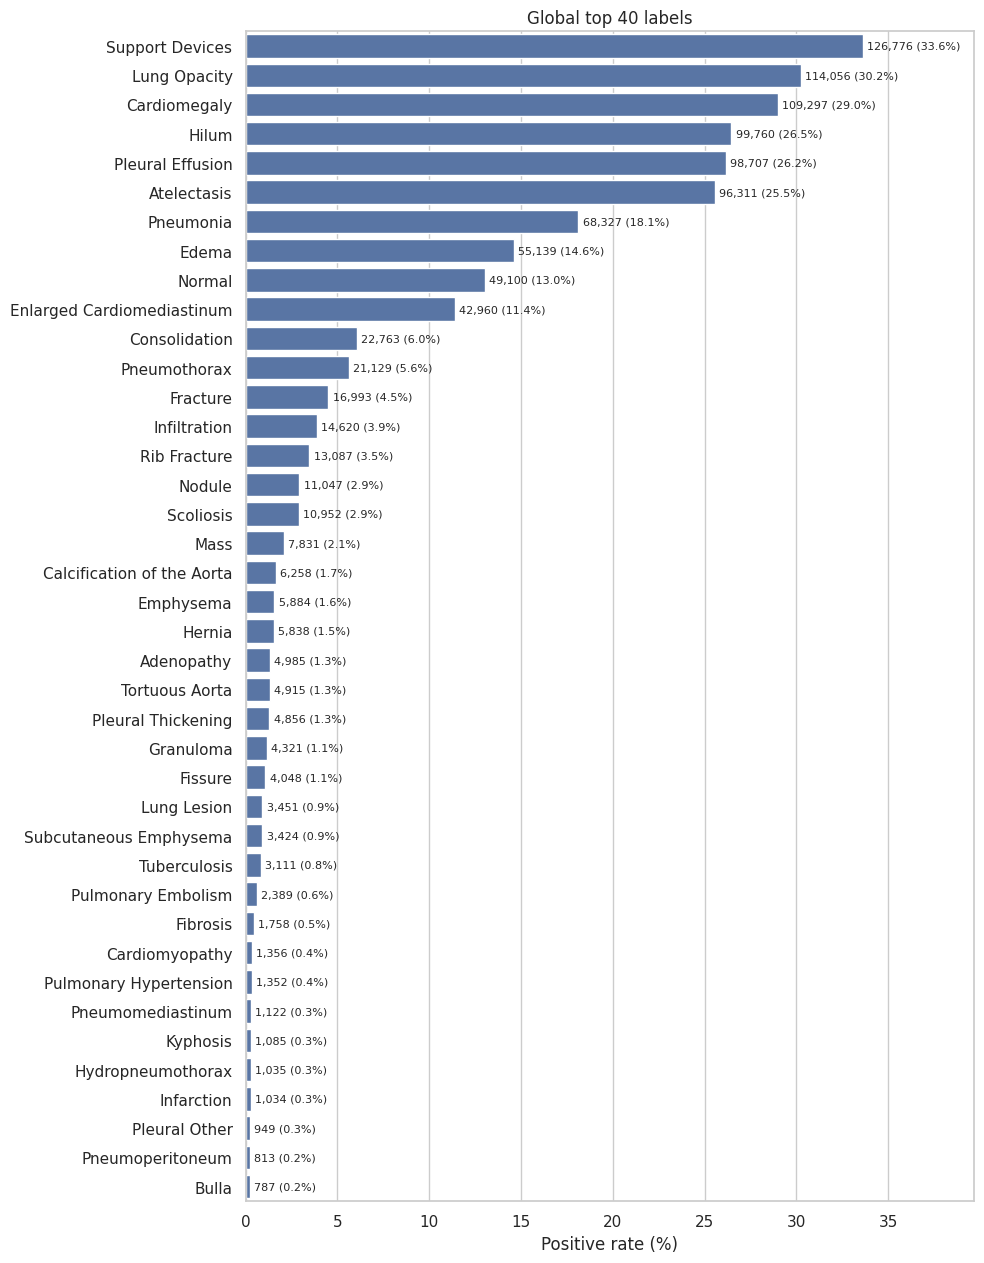

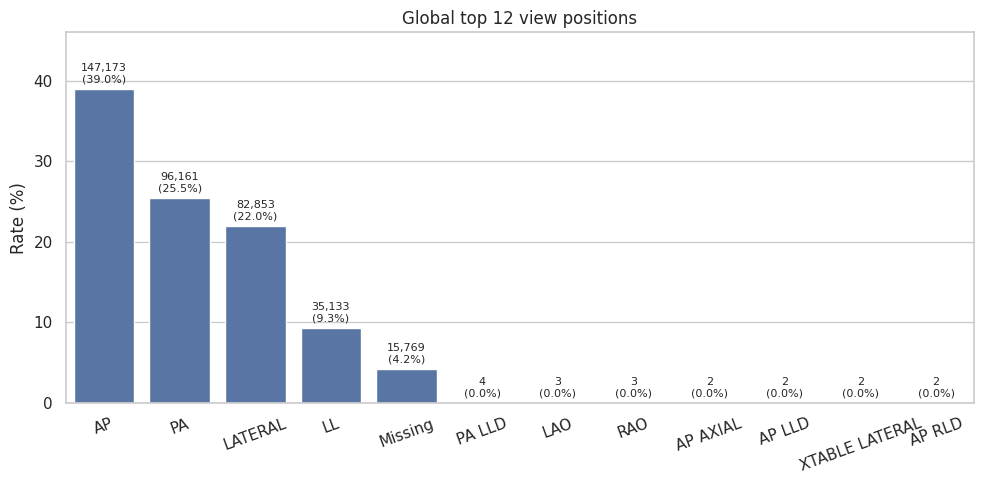

In [5]:
global_overview_df = build_split_overview(global_frames, label_cols).rename(columns={"split": "scope"})
global_label_summary_df = summarize_labels(global_df, "global", label_cols)
global_view_position_summary_df = summarize_view_positions(global_df, "global", top_n=12).rename(columns={"split": "scope"})
global_normal_conflicts_df = summarize_no_finding_conflicts(global_frames, label_cols).rename(columns={"split": "scope"})

display(global_overview_df)
display(global_label_summary_df)
display(global_view_position_summary_df)
display(global_normal_conflicts_df)

plot_global_label_prevalence(global_df, label_cols, top_n=min(40, len(label_cols)))
plot_global_view_positions(global_df, top_n=12)


## 4) Label Imbalance And Multi-Label Density


,split,label,positive_count,positive_rate_pct
0,train,Support Devices,86079,33.251697
1,train,Lung Opacity,77482,29.930738
2,train,Cardiomegaly,74738,28.870750
3,train,Hilum,68700,26.538314
4,train,Pleural Effusion,66401,25.650227
...,...,...,...,...
175,global,Osteopenia,501,0.132852
176,global,Round(ed) Atelectasis,287,0.076105
177,global,Azygos Lobe,272,0.072127
178,global,Clavicle Fracture,235,0.062316


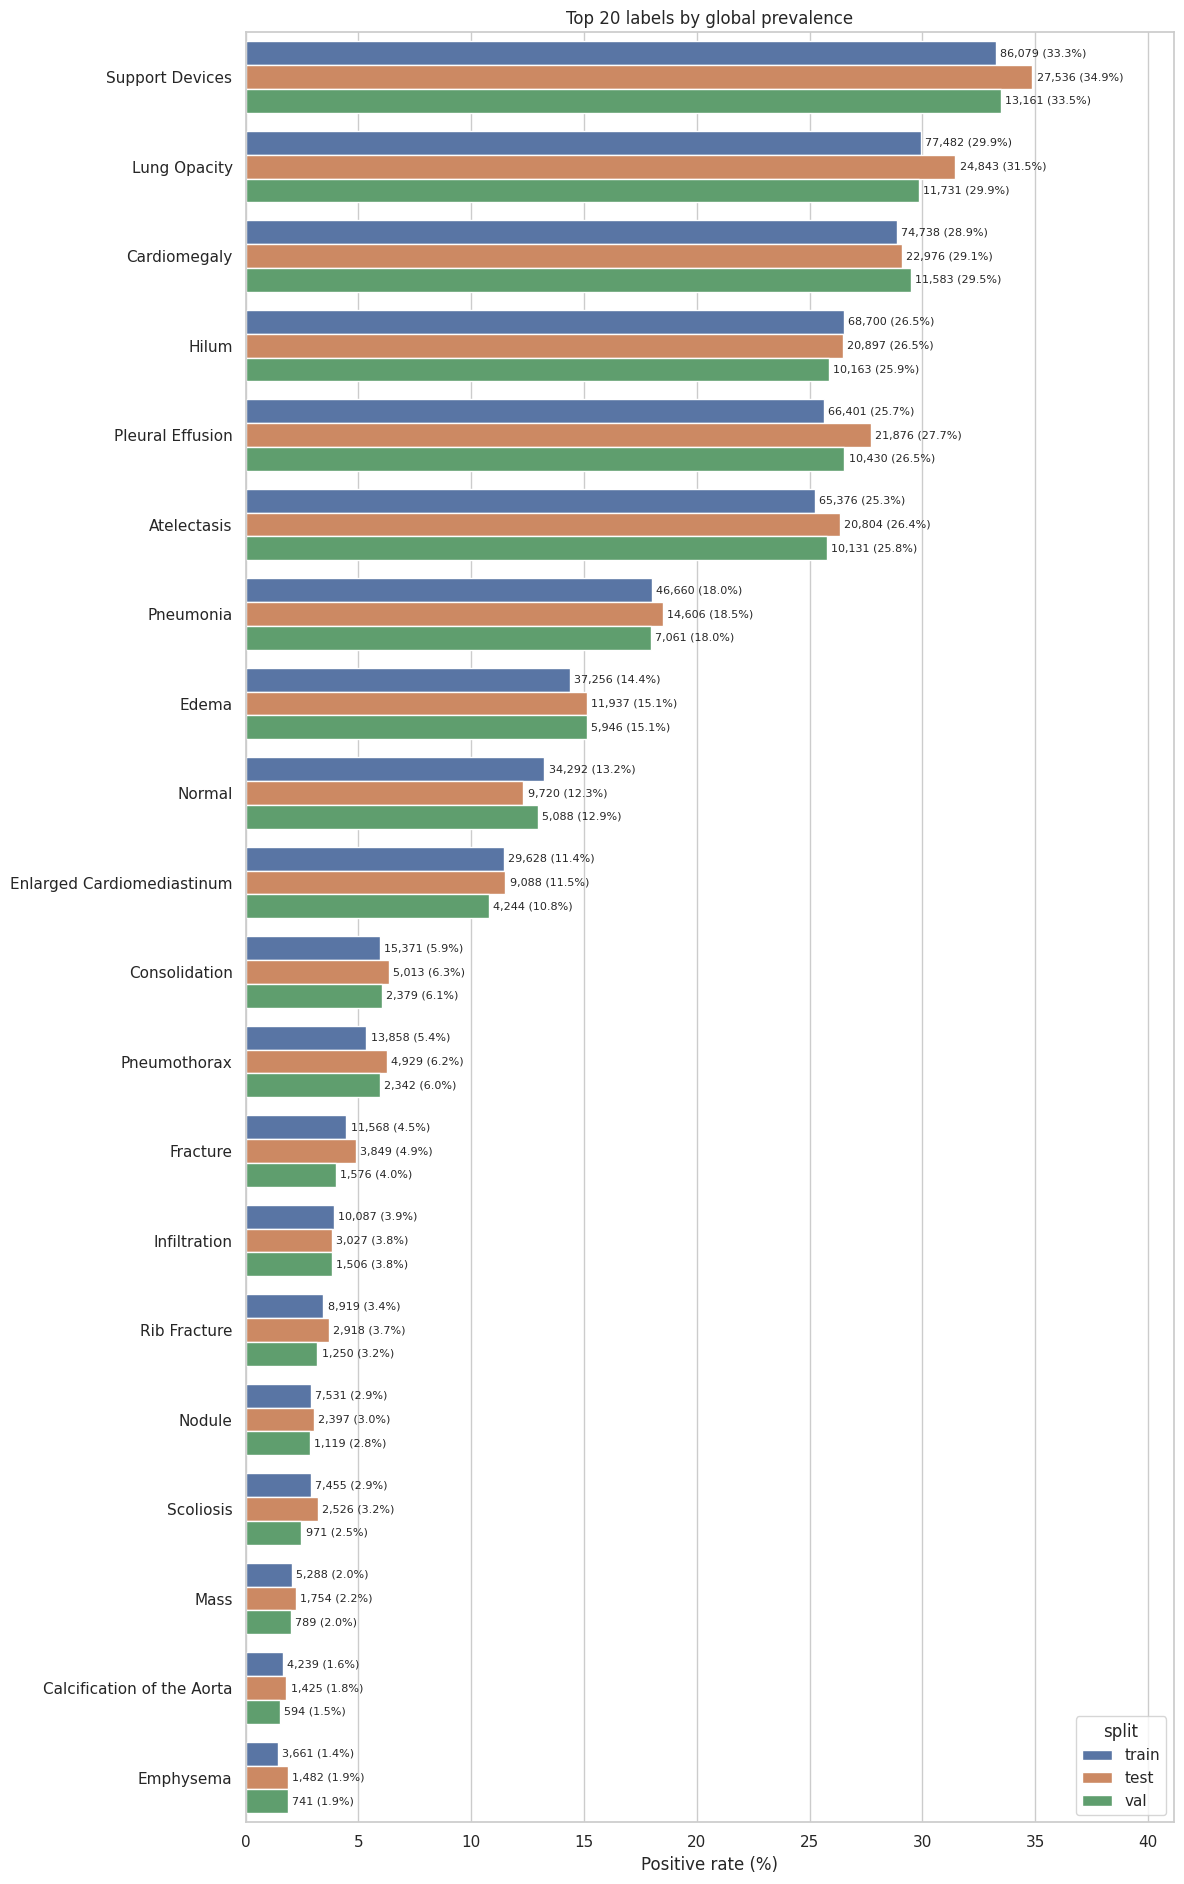

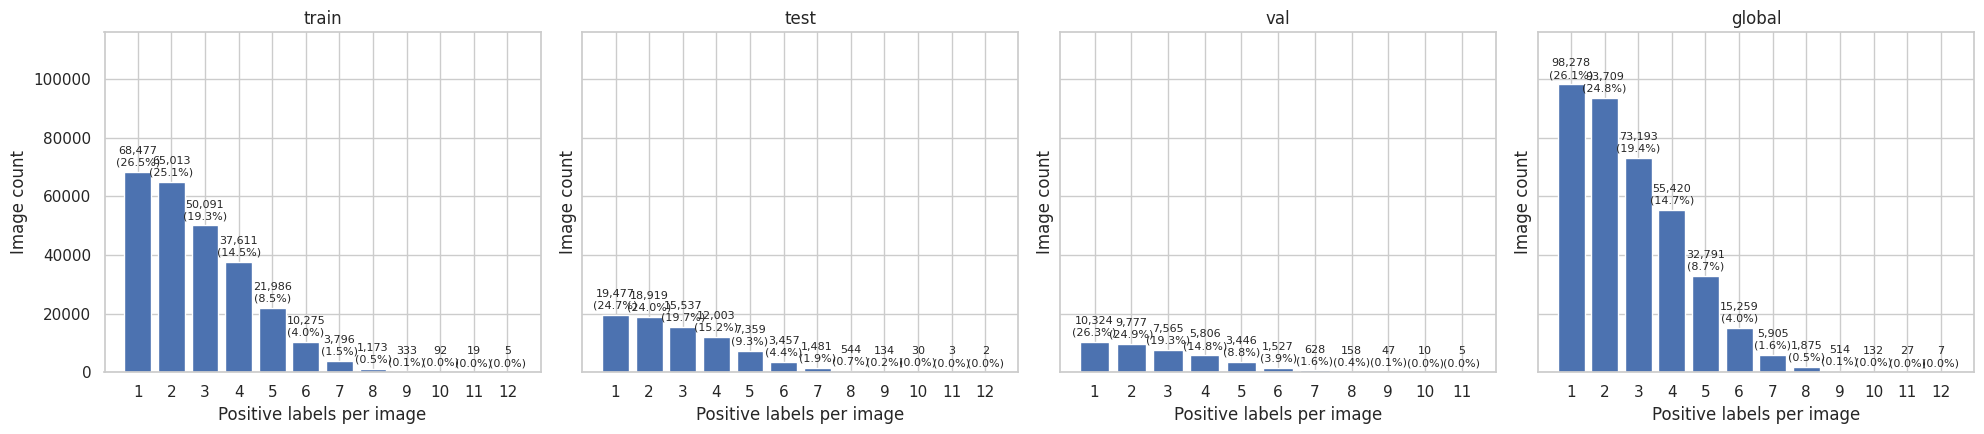

In [6]:
label_summary_df = pd.concat(
    [summarize_labels(df, split_name, label_cols) for split_name, df in analysis_splits.items()],
    ignore_index=True,
)
label_summary_with_global_df = pd.concat([label_summary_df, global_label_summary_df], ignore_index=True)

display(label_summary_with_global_df)
plot_label_prevalence(analysis_splits, label_cols, global_df, top_n=20)
plot_labels_per_image(analysis_splits, label_cols)


## 5) View Metadata And Split Leakage Checks


,split,ViewPosition,count,rate_pct,scope
0,train,AP,100024,38.638550,NaN
1,train,PA,66470,25.676882,NaN
2,train,LATERAL,57546,22.229605,NaN
3,train,LL,24080,9.301930,NaN
4,train,Missing,10734,4.146467,NaN
5,train,LAO,3,0.001159,NaN
6,train,RAO,3,0.001159,NaN
7,train,PA LLD,3,0.001159,NaN
8,train,AP AXIAL,2,0.000773,NaN
9,train,XTABLE LATERAL,2,0.000773,NaN


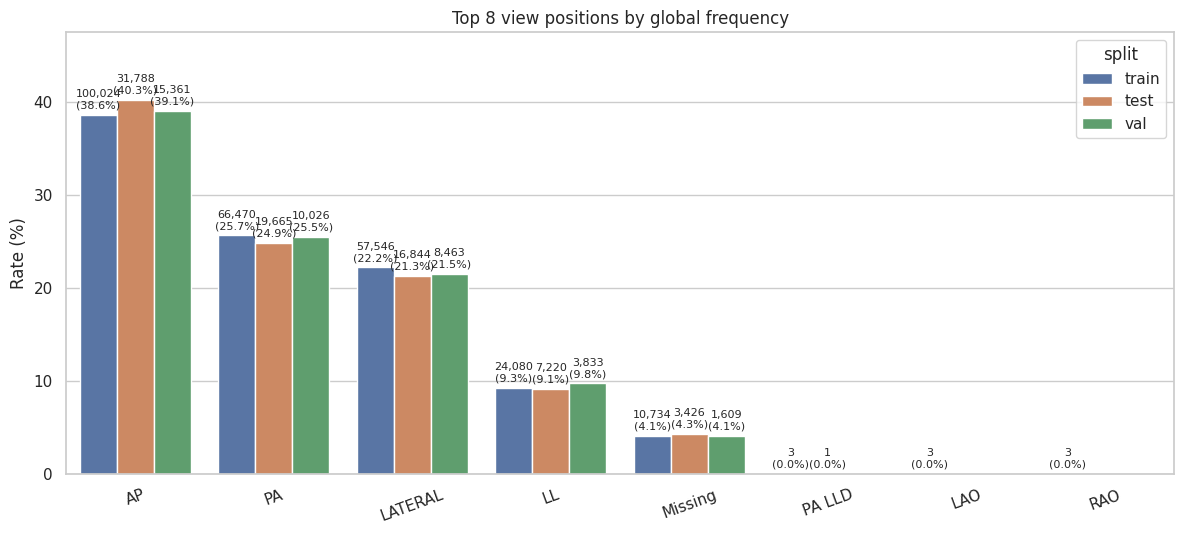

Subject overlap across splits


,train,test,val
train,45480.0,0.0,0.0
test,0.0,13078.0,0.0
val,0.0,0.0,6821.0


Study overlap across splits


,train,test,val
train,155823.0,0.0,0.0
test,0.0,48212.0,0.0
val,0.0,0.0,23800.0


DICOM overlap across splits


,train,test,val
train,258871.0,0.0,0.0
test,0.0,78946.0,0.0
val,0.0,0.0,39293.0


In [7]:
view_position_summary_df = pd.concat(
    [summarize_view_positions(df, split_name, top_n=999) for split_name, df in analysis_splits.items()],
    ignore_index=True,
)
view_position_summary_with_global_df = pd.concat([view_position_summary_df, global_view_position_summary_df], ignore_index=True)

display(view_position_summary_with_global_df)
plot_view_positions(analysis_splits, global_df, top_n=8)

print("Subject overlap across splits")
display(compute_overlap(analysis_splits, "subject_id"))
print("Study overlap across splits")
display(compute_overlap(analysis_splits, "study_id"))
print("DICOM overlap across splits")
display(compute_overlap(analysis_splits, "dicom_id"))


## 6) Study-Level Aggregation


,split,studies,single_image_studies_count,single_image_studies_pct,median_images_per_study,frontal_and_lateral_studies_count,frontal_and_lateral_studies_pct,pa_and_lateral_studies_pct,ap_and_lateral_studies_pct,median_positive_labels_per_study
0,train,155823,69478,44.587769,2.0,72791,46.713900,37.791597,9.010223,3.0
1,test,48212,22422,46.507094,2.0,21480,44.553223,36.156973,8.452253,3.0
2,val,23800,10775,45.273109,2.0,10967,46.079832,37.563025,8.596639,3.0


,scope,studies,single_image_studies_count,single_image_studies_pct,median_images_per_study,frontal_and_lateral_studies_count,frontal_and_lateral_studies_pct,pa_and_lateral_studies_pct,ap_and_lateral_studies_pct,median_positive_labels_per_study
0,global,227835,102675,45.065508,2.0,105238,46.190445,37.421818,8.848948,3.0


,split,view_combo,study_count,total_studies,study_rate_pct
0,test,AP,24474,48212,50.763295
14,test,LATERAL + PA,11627,48212,24.116403
18,test,LL + PA,5774,48212,11.976271
3,test,AP + LATERAL,3580,48212,7.425537
20,test,MISSING,1616,48212,3.351863
16,test,LL + MISSING,478,48212,0.991454
6,test,AP + LL,466,48212,0.966564
22,test,PA,91,48212,0.188750
10,test,AP + PA,28,48212,0.058077
11,test,LATERAL,23,48212,0.047706


,split,view_combo,study_count,total_studies,study_rate_pct
0,global,AP,112280,227835,49.281278
24,global,LATERAL + PA,56942,227835,24.992648
30,global,LL + PA,28114,227835,12.339632
3,global,AP + LATERAL,17663,227835,7.752540
33,global,MISSING,7292,227835,3.200562
7,global,AP + LL,2303,227835,1.010819
28,global,LL + MISSING,2145,227835,0.941471
35,global,PA,478,227835,0.209801
20,global,LATERAL,154,227835,0.067593
5,global,AP + LATERAL + PA,136,227835,0.059692


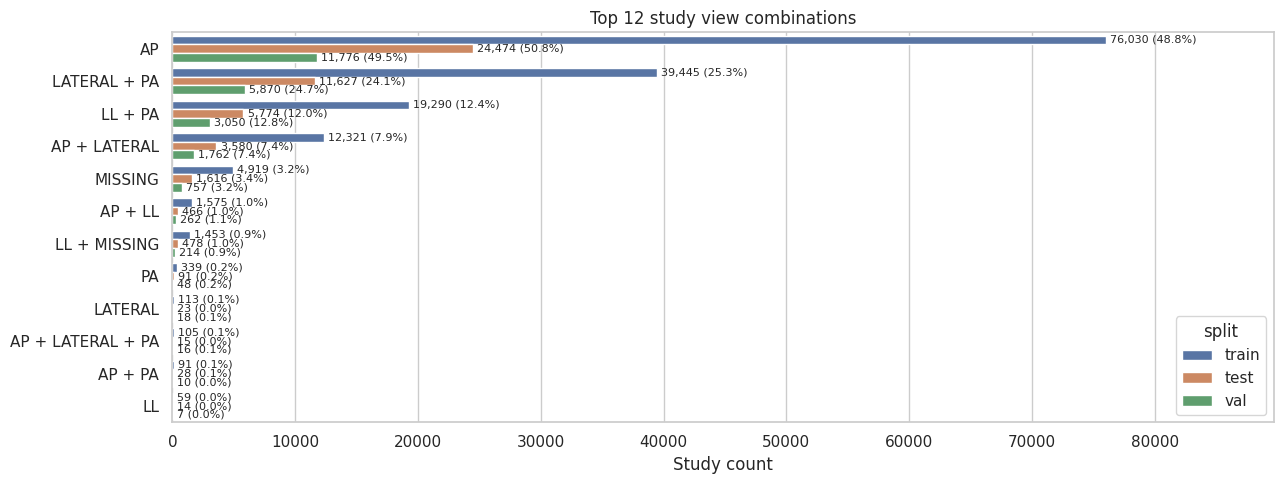

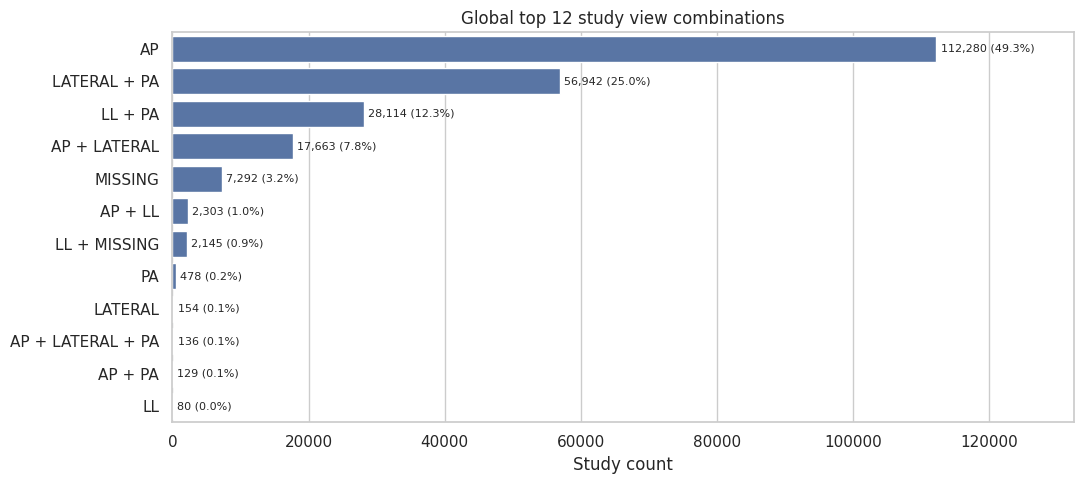

In [8]:
study_table_df, study_view_summary_df = summarize_study_views(analysis_splits, label_cols)
global_study_table_df, global_study_view_summary_df = summarize_study_views(global_frames, label_cols)
global_study_view_summary_df = global_study_view_summary_df.rename(columns={"split": "scope"})

display(study_view_summary_df)
display(global_study_view_summary_df)

display(summarize_view_combos(study_table_df).sort_values(["split", "study_count"], ascending=[True, False]).head(30))
display(summarize_view_combos(global_study_table_df).sort_values("study_count", ascending=False).head(20))

plot_top_view_combos(study_table_df, top_n=12)
plot_global_top_view_combos(global_study_table_df, top_n=12)


## 7) Patient Timeline Behavior


In [9]:
metadata_df, metadata_path = load_first_existing(
    [
        mimic_cxr_jpg_dir / "mimic-cxr-2.0.0-metadata.csv.gz",
        mimic_cxr_jpg_dir / "mimic-cxr-2.0.0-metadata.csv",
    ]
)

if metadata_df is None:
    print("MIMIC-CXR-JPG metadata was not found. Timeline cells will fall back to study_id ordering.")
    metadata_for_join = pd.DataFrame(columns=["dicom_id", "study_datetime"])
else:
    print(f"Loaded metadata: {metadata_path}")
    metadata_df["study_datetime"] = parse_mimic_study_datetime(metadata_df)
    metadata_columns = [
        column
        for column in [
            "dicom_id",
            "StudyDate",
            "StudyTime",
            "study_datetime",
            "PerformedProcedureStepDescription",
            "ProcedureCodeSequence_CodeMeaning",
            "Rows",
            "Columns",
        ]
        if column in metadata_df.columns
    ]
    metadata_for_join = metadata_df[metadata_columns].copy()

all_labeled_images_df = global_df.merge(metadata_for_join, on="dicom_id", how="left")
print(f"Rows with parsed study_datetime: {all_labeled_images_df['study_datetime'].notna().sum():,} / {len(all_labeled_images_df):,}")
display(all_labeled_images_df.head(3))


Loaded metadata: /home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/MIMIC-CXR-JPG/mimic-cxr-2.0.0-metadata.csv.gz
Rows with parsed study_datetime: 377,110 / 377,110


,dicom_id,subject_id,study_id,ViewPosition,ViewCodeSequence_CodeMeaning,fpath,Adenopathy,Atelectasis,Azygos Lobe,Bulla,Calcification of the Aorta,Cardiomegaly,Cardiomyopathy,Clavicle Fracture,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fissure,Fracture,Granuloma,Hernia,Hilum,Hydropneumothorax,Infarction,Infiltration,Kyphosis,Lobar Atelectasis,Lung Lesion,Lung Opacity,Mass,Nodule,Normal,Osteopenia,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Pulmonary Embolism,Pulmonary Hypertension,Rib Fracture,Round(ed) Atelectasis,Scoliosis,Subcutaneous Emphysema,Support Devices,Tortuous Aorta,Tuberculosis,split,StudyDate,StudyTime,study_datetime,PerformedProcedureStepDescription,ProcedureCodeSequence_CodeMeaning,Rows,Columns
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,10000032,s50414267,PA,postero-anterior,files/p10/p10000032/s50414267/02aa804e-bde0afd...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,train,21800506,213014.531,2180-05-06 21:30:14,CHEST (PA AND LAT),CHEST (PA AND LAT),3056,2544
1,174413ec-4ec4c1f7-34ea26b7-c5f994f8-79ef1962,10000032,s50414267,LATERAL,lateral,files/p10/p10000032/s50414267/174413ec-4ec4c1f...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,train,21800506,213014.531,2180-05-06 21:30:14,CHEST (PA AND LAT),CHEST (PA AND LAT),3056,2544
2,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,10000032,s53189527,PA,postero-anterior,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,train,21800626,165500.312,2180-06-26 16:55:00,CHEST (PA AND LAT),CHEST (PA AND LAT),3056,2544


In [10]:
study_timeline_df = build_study_timeline(all_labeled_images_df, label_cols, scope_columns=["split"])
global_study_timeline_df = build_study_timeline(all_labeled_images_df, label_cols)

patient_timeline_summary_df, split_patient_summary_df = summarize_patient_timelines(study_timeline_df, scope_columns=["split"])
global_patient_timeline_summary_df, global_patient_summary_df = summarize_patient_timelines(global_study_timeline_df)

display(split_patient_summary_df)
display(global_patient_summary_df)
display(global_patient_timeline_summary_df.sort_values(["study_count", "span_days"], ascending=[False, False]).head(10))


,split,patients,patients_with_multiple_studies,median_studies_per_patient,max_studies_per_patient,median_span_days,max_span_days,multiple_study_patient_pct
0,test,13078,6541,2.0,131,0.027112,1846.212303,50.015293
1,train,45480,22713,1.0,158,0.000000,1845.636748,49.940633
2,val,6821,3430,2.0,108,0.124873,1817.607859,50.285882


,scope,patients,patients_with_multiple_studies,median_studies_per_patient,max_studies_per_patient,median_span_days,max_span_days,multiple_study_patient_pct
0,global,65379,32684,1.0,158,0.0,1846.212303,49.991588


,subject_id,study_count,first_study_datetime,last_study_datetime,total_images,span_days
42053,16454913,158,2144-06-30 14:40:38,2146-06-26 04:44:30,174,725.586019
38717,15936063,131,2161-02-05 15:09:55,2164-08-22 10:04:33,142,1293.787940
54221,18295542,127,2157-11-07 22:44:17,2161-12-31 14:02:37,131,1514.637731
13258,12043836,124,2135-10-29 18:22:24,2139-09-29 12:59:46,167,1430.775949
63236,19674244,108,2193-10-28 16:01:58,2197-01-02 05:18:06,130,1161.552870
37160,15689523,104,2158-03-20 12:39:57,2159-09-15 16:33:08,119,544.161933
47425,17277688,96,2184-02-12 14:36:11,2186-11-13 17:49:48,113,1005.134456
43412,16662316,95,2174-12-08 01:06:57,2178-05-16 02:27:54,169,1255.056215
11071,11717909,95,2129-09-12 20:50:52,2132-02-21 10:40:56,114,891.576435
4532,10699336,89,2158-01-08 05:52:15,2158-04-16 12:21:40,98,98.270428


## 8) Global Label Co-Occurrence And Correlations


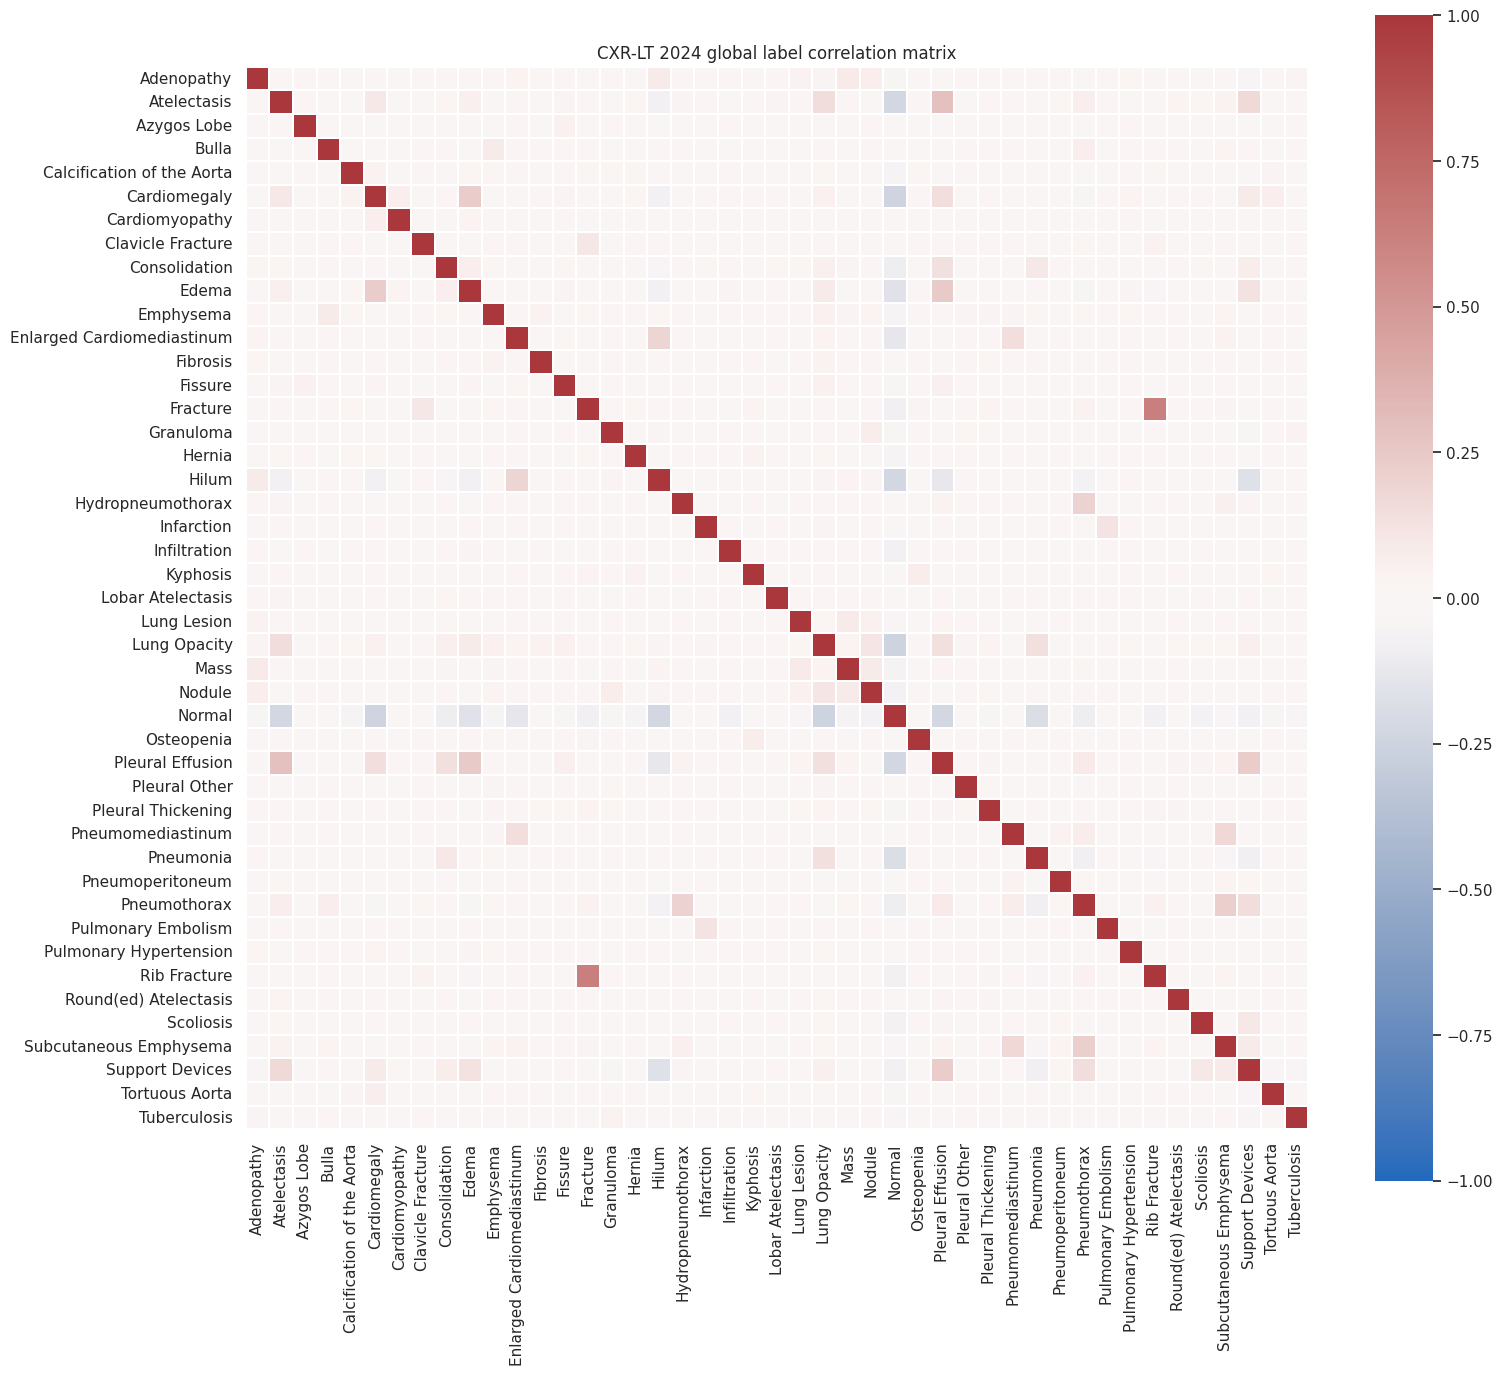

Most positively correlated label pairs


,left_label,right_label,correlation,cooccurrence_count,left_positive_count,right_positive_count
548,Fracture,Rib Fracture,0.628054,9582,16993,13087
71,Atelectasis,Pleural Effusion,0.291589,46288,96311,98707
379,Edema,Pleural Effusion,0.247489,28928,55139,98707
213,Cardiomegaly,Edema,0.229485,29853,109297,55139
882,Pleural Effusion,Support Devices,0.229201,51132,98707,126776
950,Pneumothorax,Subcutaneous Emphysema,0.222111,2019,21129,3424
655,Hydropneumothorax,Pneumothorax,0.202328,976,1035,21129
434,Enlarged Cardiomediastinum,Hilum,0.192183,21521,42960,99760
920,Pneumomediastinum,Subcutaneous Emphysema,0.179043,359,1122,3424
84,Atelectasis,Support Devices,0.169815,45570,96311,126776


Most negatively correlated label pairs


,left_label,right_label,correlation,cooccurrence_count,left_positive_count,right_positive_count
782,Lung Opacity,Normal,-0.254762,0,114056,49100
231,Cardiomegaly,Normal,-0.247164,0,109297,49100
621,Hilum,Normal,-0.232039,0,99760,49100
838,Normal,Pleural Effusion,-0.230374,0,49100,98707
69,Atelectasis,Normal,-0.226588,0,96311,49100
842,Normal,Pneumonia,-0.181998,0,49100,68327
636,Hilum,Support Devices,-0.170697,20124,99760,126776
377,Edema,Normal,-0.160110,0,55139,49100
444,Enlarged Cardiomediastinum,Normal,-0.138726,0,42960,49100
623,Hilum,Pleural Effusion,-0.125339,16947,99760,98707


In [11]:
global_corr_df = global_df[label_cols].corr()
pair_corr_df = label_pair_correlation_table(global_df, label_cols)

plt.figure(figsize=(16, 14))
sns.heatmap(global_corr_df, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=0.2)
plt.title("CXR-LT 2024 global label correlation matrix")
plt.tight_layout()
plt.show()

print("Most positively correlated label pairs")
display(pair_corr_df.sort_values("correlation", ascending=False).head(20))

print("Most negatively correlated label pairs")
display(pair_corr_df.sort_values("correlation", ascending=True).head(20))


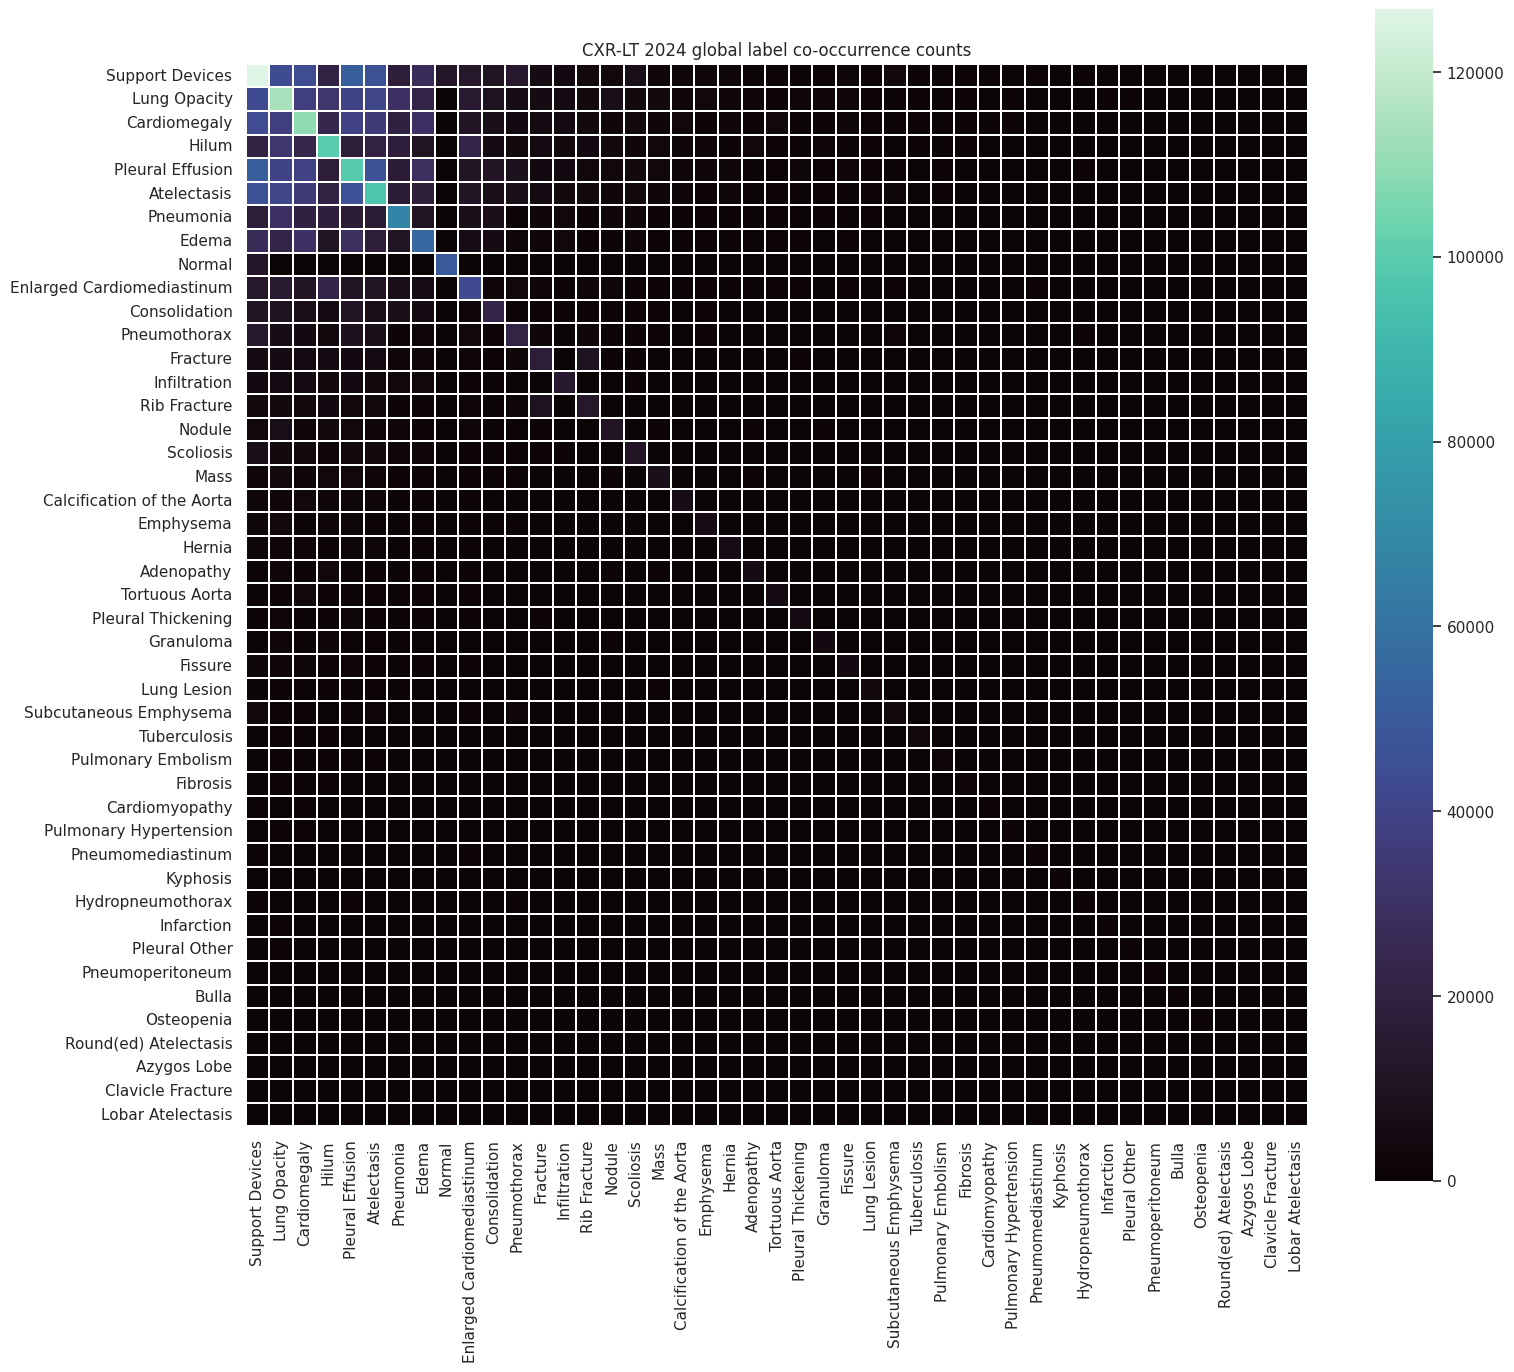

,Support Devices,Lung Opacity,Cardiomegaly,Hilum,Pleural Effusion,Atelectasis,Pneumonia,Edema,Normal,Enlarged Cardiomediastinum,Consolidation,Pneumothorax,Fracture,Infiltration,Rib Fracture
Support Devices,126776,43226,43592,20124,51132,45570,17350,26652,11911,13254,10717,13401,5132,3966,3610
Lung Opacity,43226,114056,36858,32316,40050,40627,29732,21789,0,14968,9425,6020,5430,4825,3782
Cardiomegaly,43592,36858,109297,23187,39610,35161,19368,29853,0,11517,7132,4443,4706,4546,3221
Hilum,20124,32316,23187,99760,16947,19868,18417,10288,0,21521,4725,3120,4570,3139,3993
Pleural Effusion,51132,40050,39610,16947,98707,46288,16606,28928,0,10874,11427,8912,4240,3993,2951
Atelectasis,45570,40627,35161,19868,46288,96311,16014,17456,0,11623,6452,7764,4627,3347,3325
Pneumonia,17350,29732,19368,18417,16606,16014,68327,10313,0,7323,7516,1130,2333,2586,1454
Edema,26652,21789,29853,10288,28928,17456,10313,55139,0,5541,5427,1849,1788,2794,1012
Normal,11911,0,0,0,0,0,0,0,49100,0,0,0,0,0,0
Enlarged Cardiomediastinum,13254,14968,11517,21521,10874,11623,7323,5541,0,42960,2151,2629,2069,1363,1624


In [12]:
global_cooccurrence_df = global_df[label_cols].T.dot(global_df[label_cols])
label_order = global_df[label_cols].sum().sort_values(ascending=False).index

plt.figure(figsize=(16, 14))
sns.heatmap(global_cooccurrence_df.loc[label_order, label_order], cmap="mako", square=True, linewidths=0.2)
plt.title("CXR-LT 2024 global label co-occurrence counts")
plt.tight_layout()
plt.show()

display(global_cooccurrence_df.loc[label_order, label_order].iloc[:15, :15])


## 9) View-Conditioned Prevalence


,split,ViewPosition,row_count
135,test,AP,31788
180,test,LATERAL,16844
225,test,PA,19665
0,train,AP,100024
45,train,LATERAL,57546
90,train,PA,66470
270,val,AP,15361
315,val,LATERAL,8463
360,val,PA,10026


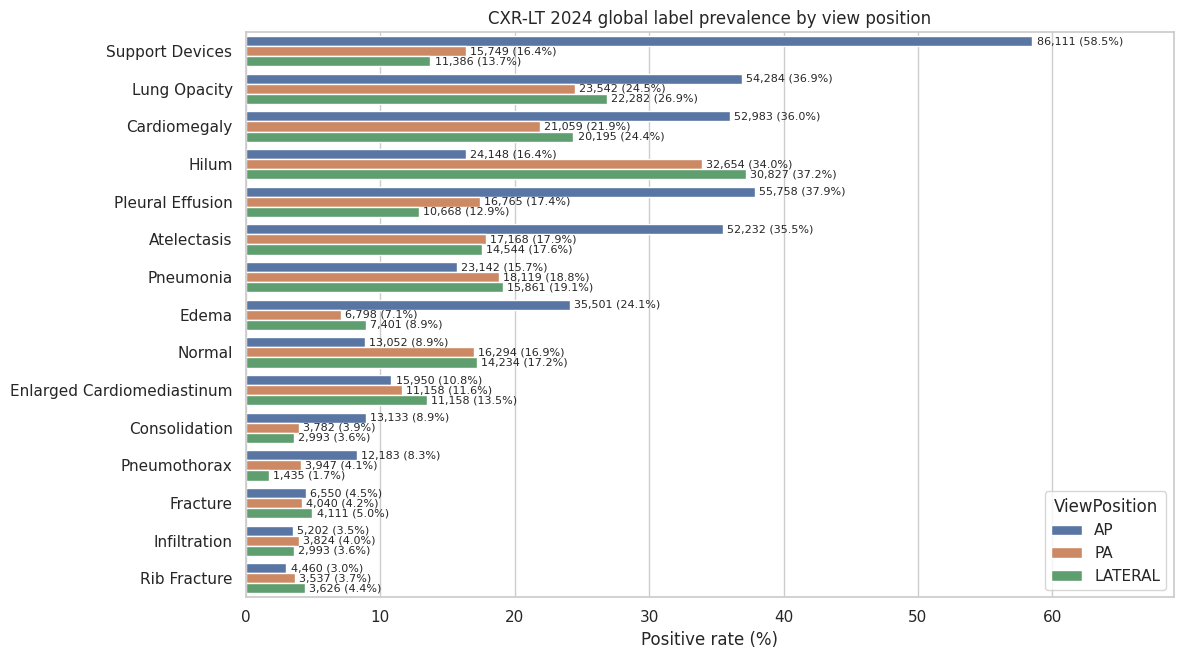

ViewPosition,AP,LATERAL,PA
label,,,
Support Devices,58.510,13.742,16.378
Lung Opacity,36.884,26.893,24.482
Cardiomegaly,36.000,24.374,21.900
Hilum,16.408,37.207,33.958
Pleural Effusion,37.886,12.876,17.434
Atelectasis,35.490,17.554,17.853
Pneumonia,15.724,19.144,18.842
Edema,24.122,8.933,7.069
Normal,8.868,17.180,16.944


In [13]:
view_prevalence_df = view_conditioned_prevalence(analysis_splits, label_cols)
global_view_prevalence_df = view_conditioned_prevalence(global_frames, label_cols)

display(view_prevalence_df[["split", "ViewPosition", "row_count"]].drop_duplicates().sort_values(["split", "ViewPosition"]))

top_global_labels = global_df[label_cols].sum().sort_values(ascending=False).head(15).index.tolist()
plot_view_conditioned_prevalence(global_view_prevalence_df, label_order=top_global_labels, title="CXR-LT 2024 global label prevalence by view position")

display(
    global_view_prevalence_df
    .query("label in @top_global_labels")
    .pivot(index="label", columns="ViewPosition", values="positive_rate_pct")
    .loc[top_global_labels]
    .round(3)
)


## 10) Image Availability And Path Sanity


In [14]:
image_root = mimic_cxr_jpg_dir
print(f"image_root: {image_root}")
print(f"image_root exists: {image_root.exists()}")
print(f"image files directory exists: {(image_root / 'files').exists()}")

image_path_summary_df = summarize_image_paths(analysis_splits, image_root)
global_image_path_summary_df = summarize_image_paths(global_frames, image_root).rename(columns={"split": "scope"})

display(image_path_summary_df)
display(global_image_path_summary_df)

path_column = detect_path_column(global_df)
missing_global_paths = global_df.loc[
    ~global_df[path_column].astype(str).map(lambda value: resolve_relative_path(image_root, value).is_file()),
    ["split", "dicom_id", "subject_id", "study_id", "ViewPosition", path_column],
].head(10)

print("Sample missing global image paths")
display(missing_global_paths)


image_root: /home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/MIMIC-CXR-JPG
image_root exists: True
image files directory exists: True


,split,rows,path_column,path_values,unique_paths,duplicate_path_rows,jpg_extension_rows,existing_files,missing_files,existing_file_pct
0,train,258871,fpath,258871,258871,0,258871,215249,43622,83.149136
1,test,78946,fpath,78946,78946,0,78946,64889,14057,82.194158
2,val,39293,fpath,39293,39293,0,39293,32460,6833,82.610134


,scope,rows,path_column,path_values,unique_paths,duplicate_path_rows,jpg_extension_rows,existing_files,missing_files,existing_file_pct
0,global,377110,fpath,377110,377110,0,377110,312598,64512,82.893055


Sample missing global image paths


,split,dicom_id,subject_id,study_id,ViewPosition,fpath
223043,train,c88546fd-0bbdd930-fd0f7c82-61fb1605-d1426c71,15906963,s55771811,PA,files/p15/p15906963/s55771811/c88546fd-0bbdd93...
223345,test,5377e2e1-952e81de-31164026-7b7eb33b-571b59df,15913953,s50333688,AP,files/p15/p15913953/s50333688/5377e2e1-952e81d...
223746,train,7fd59ae1-9073175d-fad4af91-40d4c862-25d73ed4,15928338,s54265959,LATERAL,files/p15/p15928338/s54265959/7fd59ae1-9073175...
294857,test,def0f6a5-9668a4d8-e335fedf-1a483dc6-e55f0939,17818490,s57155229,AP,files/p17/p17818490/s57155229/def0f6a5-9668a4d...
294858,train,1b2570b0-76177554-741ed20b-f71d01ef-f439db63,17818524,s54665660,PA,files/p17/p17818524/s54665660/1b2570b0-7617755...
294859,train,30818573-3e054f54-ae4f223c-325970ed-09cf508c,17818524,s54665660,LL,files/p17/p17818524/s54665660/30818573-3e054f5...
294860,train,0a0b5388-f492c45b-7b2aef5b-57e84a2e-0b79c4bf,17818524,s56301048,AP,files/p17/p17818524/s56301048/0a0b5388-f492c45...
294861,train,a7415880-708fc221-bd20bc0a-80407007-dcb955c1,17818524,s56301048,AP,files/p17/p17818524/s56301048/a7415880-708fc22...
294862,train,63a4f914-202b6dc8-286045ea-338fa048-2e6e49e2,17818674,s53045339,PA,files/p17/p17818674/s53045339/63a4f914-202b6dc...
294863,train,c0391b96-fa36c467-01942652-f95d20cb-75e74dc6,17818674,s53045339,LATERAL,files/p17/p17818674/s53045339/c0391b96-fa36c46...


## 11) Text Linkage Readiness


In [15]:
study_list_df, study_list_path = load_first_existing(
    [
        mimic_cxr_dir / "cxr-study-list.csv.gz",
        mimic_cxr_dir / "cxr-study-list.csv",
    ]
)

if study_list_df is None:
    print("MIMIC-CXR study list was not found. Report linkage cannot be checked.")
    report_link_summary_df = pd.DataFrame()
    global_report_link_summary_df = pd.DataFrame()
    linked_reports_df = pd.DataFrame()
    global_linked_reports_df = pd.DataFrame()
else:
    print(f"Loaded study list: {study_list_path}")
    (
        report_link_summary_df,
        global_report_link_summary_df,
        linked_reports_df,
        global_linked_reports_df,
    ) = build_report_linkage(analysis_splits, global_df, study_list_df, mimic_cxr_dir)

    print(f"report files directory exists: {(mimic_cxr_dir / 'files').exists()}")
    display(report_link_summary_df)
    display(global_report_link_summary_df)
    display(linked_reports_df.head(10))


Loaded study list: /home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/MIMIC-CXR/cxr-study-list.csv.gz
report files directory exists: True


,split,studies,studies_with_report_index,studies_with_report_file,report_index_pct,report_file_pct
0,test,48212,48212,43900,100.0,91.056169
1,train,155823,155823,141334,100.0,90.701629
2,val,23800,23800,21597,100.0,90.743697


,scope,studies,studies_with_report_index,studies_with_report_file,report_index_pct,report_file_pct
0,global,227835,227835,206831,100.0,90.781048


,subject_id,study_id,study_id_norm,split,report_path,has_report_index,report_file_exists
0,10000032,s50414267,50414267,train,files/p10/p10000032/s50414267.txt,True,True
1,10000032,s53189527,53189527,train,files/p10/p10000032/s53189527.txt,True,True
2,10000032,s53911762,53911762,train,files/p10/p10000032/s53911762.txt,True,True
3,10000032,s56699142,56699142,train,files/p10/p10000032/s56699142.txt,True,True
4,10000764,s57375967,57375967,train,files/p10/p10000764/s57375967.txt,True,True
5,10000898,s50771383,50771383,train,files/p10/p10000898/s50771383.txt,True,True
6,10000898,s54205396,54205396,train,files/p10/p10000898/s54205396.txt,True,True
7,10001038,s58224503,58224503,train,files/p10/p10001038/s58224503.txt,True,True
8,10001122,s53447138,53447138,train,files/p10/p10001122/s53447138.txt,True,True
9,10001122,s53957785,53957785,train,files/p10/p10001122/s53957785.txt,True,True


In [16]:
if global_linked_reports_df.empty or not global_linked_reports_df["report_file_exists"].any():
    print("No local report text files were found to preview.")
else:
    sample_report_row = global_linked_reports_df.query("report_file_exists").iloc[0]
    print(
        "Sample report: "
        f"subject_id={sample_report_row['subject_id']}, "
        f"study_id={sample_report_row['study_id']}"
    )
    print(read_report_text(mimic_cxr_dir, sample_report_row["report_path"]))


Sample report: subject_id=10000032, study_id=s50414267
                                 FINAL REPORT
 EXAMINATION:  CHEST (PA AND LAT)
 
 INDICATION:  ___F with new onset ascites  // eval for infection
 
 TECHNIQUE:  Chest PA and lateral
 
 COMPARISON:  None.
 
 FINDINGS: 
 
 There is no focal consolidation, pleural effusion or pneumothorax.  Bilateral
 nodular opacities that most likely represent nipple shadows. The
 cardiomediastinal silhouette is normal.  Clips project over the left lung,
 potentially within the breast. The imaged upper abdomen is unremarkable.
 Chronic deformity of the posterior left sixth and seventh ribs are noted.
 
 IMPRESSION: 
 
 No acute cardiopulmonary process.



## Notes For The Next Modeling Pass

Use these outputs to decide whether the active dataloader should target the 2023 label set, the larger 2024 task-1 label set, or a shared-label compatibility subset.
